In [11]:
%matplotlib inline

import pandas as pd
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# DEPENDENCY: install the xlrd pip package to be able to read excel using pandas (pip install xlrd)
import warnings
warnings.filterwarnings('ignore')

import lib.databaseGateway as db
import lib.configurationProvider as config

In [12]:
static_raw = pd.read_csv("results/recallStaticResults.csv", index_col=0)
annotations = pd.read_csv("results/recallAnnotations.csv")
# static_raw = pd.read_csv("results/recallStaticResultsFiltered.csv", index_col=0)
# annotations = pd.read_csv("results/recallAnnotationsFiltered.csv")
filepaths, _, _, _ = db.get_MVK_metadata()
dataset_size = len(filepaths)

static_raw["IoU"].mean()

0.28387874928069046

In [13]:
# Preprocess data to split global/object descriptions
ranks_global = static_raw.drop(["desc_object", "rank_object"], axis=1).rename(columns={"desc_global": "desc", "rank_global": "rank"})
ranks_global["annotation_type"] = "global"

ranks_object = static_raw.drop(["desc_global", "rank_global"], axis=1).rename(columns={"desc_object": "desc", "rank_object": "rank"})
ranks_object["annotation_type"] = "object"

merged_ranks = pd.concat([ranks_global, ranks_object], ignore_index=True)
merged_ranks.head()

,author,annotation_id,bucket,annotation_order,bucket_order,rect_type,kind,model_year,frame_idx,desc,rank,IoU,annotation_type
0,5ec14b142a92684125500c16,0,0,GF,STD,initial_rect,9_piece_0,2025,34769,a diver swimming over a whale in deep water,2405,0.276856,global
1,5ec14b142a92684125500c16,0,0,GF,STD,final_rect,9_piece_0,2025,34769,a diver swimming over a whale in deep water,2279,0.171345,global
2,5ec14b142a92684125500c16,1,0,GF,STD,initial_rect,9_piece_0,2025,34281,a flatfish having a swim next to coral,41370,0.298520,global
3,5ec14b142a92684125500c16,1,0,GF,STD,final_rect,9_piece_0,2025,34281,a flatfish having a swim next to coral,41370,0.278474,global
4,5ec14b142a92684125500c16,2,0,GF,STD,initial_rect,9_piece_0,2025,76415,"bad quality picture of deep waters, a coral re...",79201,0.250997,global


In [14]:
# Define filtering function
def get_filtered_ranks(rect_type: str = None, kind: str = None, model_year: int = None, annotation_type: str = None, annotation_order: str = None, bucket_order: str = None):
    filter_condition = pd.Series([True] * len(merged_ranks))
    
    if rect_type is not None:
        filter_condition &= (merged_ranks["rect_type"] == rect_type)
    if kind is not None:
        filter_condition &= (merged_ranks["kind"] == kind)
    if model_year is not None:
        filter_condition &= (merged_ranks["model_year"] == model_year)
    if annotation_type is not None:
        filter_condition &= (merged_ranks["annotation_type"] == annotation_type)
    if annotation_order is not None:
        filter_condition &= (merged_ranks["annotation_order"] == annotation_order)
    if bucket_order is not None:
        filter_condition &= (merged_ranks["bucket_order"] == bucket_order)
        
    return merged_ranks[filter_condition]

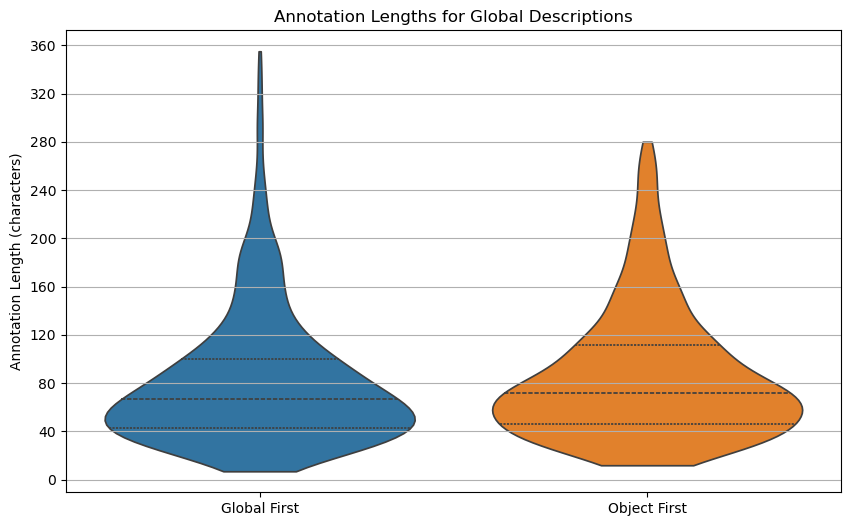

In [15]:
annotation_type = "global"

# compare global annotation lengths for global first vs object first
global_first = get_filtered_ranks(annotation_type=annotation_type, kind="whole", rect_type="initial_rect", annotation_order="GF")
object_first = get_filtered_ranks(annotation_type=annotation_type, kind="whole", rect_type="initial_rect", annotation_order="LF")

# remove top percentile of annotation lengths to remove outliers
global_first = global_first[global_first["desc"].apply(len) < global_first["desc"].apply(len).quantile(0.99)]
object_first = object_first[object_first["desc"].apply(len) < object_first["desc"].apply(len).quantile(0.99)]

global_first_lengths = global_first["desc"].apply(len).to_list()
object_first_lengths = object_first["desc"].apply(len).to_list()

# plot two violin plots side by side for global first and object first, with quartile lines and median line that meet in the middle of the plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=[global_first_lengths, object_first_lengths], inner="quartile", cut=0)
plt.xticks([0, 1], ["Global First", "Object First"])
plt.title(f"Annotation Lengths for {annotation_type.capitalize()} Descriptions")
plt.ylabel("Annotation Length (characters)")
# make the lines every 50 characters
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(40))
plt.grid(axis="y")
plt.show()


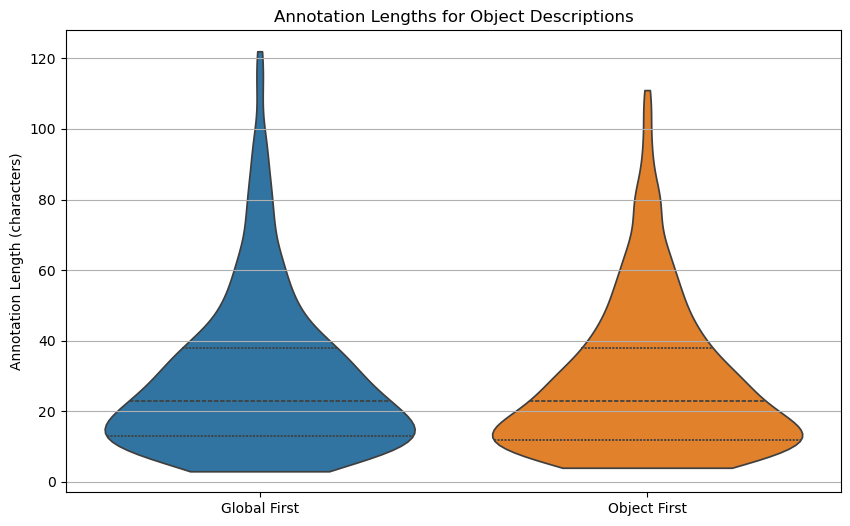

In [16]:
annotation_type = "object"

# compare global annotation lengths for global first vs object first
global_first = get_filtered_ranks(annotation_type=annotation_type, kind="whole", rect_type="initial_rect", annotation_order="GF")
object_first = get_filtered_ranks(annotation_type=annotation_type, kind="whole", rect_type="initial_rect", annotation_order="LF")

# remove top percentile of annotation lengths to remove outliers
global_first = global_first[global_first["desc"].apply(len) < global_first["desc"].apply(len).quantile(0.99)]
object_first = object_first[object_first["desc"].apply(len) < object_first["desc"].apply(len).quantile(0.99)]

global_first_lengths = global_first["desc"].apply(len).to_list()
object_first_lengths = object_first["desc"].apply(len).to_list()

# plot two violin plots side by side for global first and object first, with quartile lines and median line that meet in the middle of the plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=[global_first_lengths, object_first_lengths], inner="quartile", cut=0)
plt.xticks([0, 1], ["Global First", "Object First"])
plt.title(f"Annotation Lengths for {annotation_type.capitalize()} Descriptions")
plt.ylabel("Annotation Length (characters)")
# make the lines every 50 characters
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(20))
plt.grid(axis="y")
plt.show()


Global GF median: 67.00
Global LF median: 72.00
Object GF median: 23.00
Object LF median: 23.00


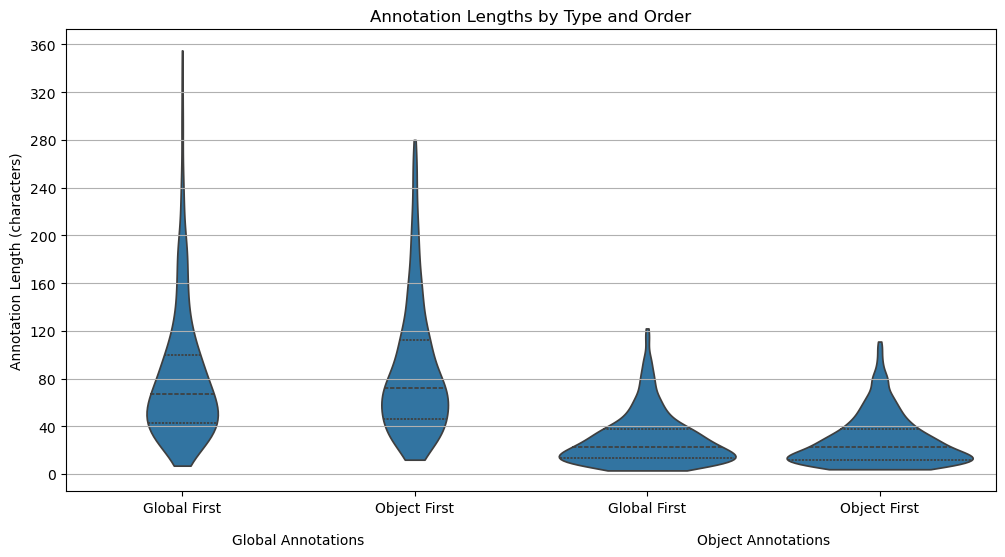

In [17]:
# Combined violin plot: global/object x GF/LF in one chart
groups = [
    ("global", "GF", "Global"),
    ("global", "LF", "Global"),
    ("object", "GF", "Object"),
    ("object", "LF", "Object"),
]

rows = []
for ann_type, ann_order, label in groups:
    subset = get_filtered_ranks(
        annotation_type=ann_type,
        kind="whole",
        rect_type="initial_rect",
        annotation_order=ann_order,
).copy()
    lengths = subset["desc"].apply(len)
    lengths = lengths[lengths < lengths.quantile(0.99)]
    print(f"{label} {ann_order} median: {lengths.median():.2f}")
    rows.extend({"group": label, "order": ann_order, "length": value} for value in lengths)

combined_lengths = pd.DataFrame(rows)
combined_lengths["group_order"] = combined_lengths["group"] + "|" + combined_lengths["order"]

order = ["Global|GF", "Global|LF", "Object|GF", "Object|LF"]

plt.figure(figsize=(12, 6))
ax = sns.violinplot(
    data=combined_lengths,
    x="group_order",
    y="length",
    order=order,
    inner="quartile",
    cut=0,
)
ax.set_title("Annotation Lengths by Type and Order")
ax.set_ylabel("Annotation Length (characters)")
ax.set_xlabel("")
ax.set_xticklabels(["Global First", "Object First", "Global First", "Object First"])

# Add group labels centered under each pair
ax.text(0.5, -0.09, "Global Annotations", ha="center", va="top", transform=ax.get_xaxis_transform())
ax.text(2.5, -0.09, "Object Annotations", ha="center", va="top", transform=ax.get_xaxis_transform())
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(40))
plt.grid(axis="y")
plt.show()

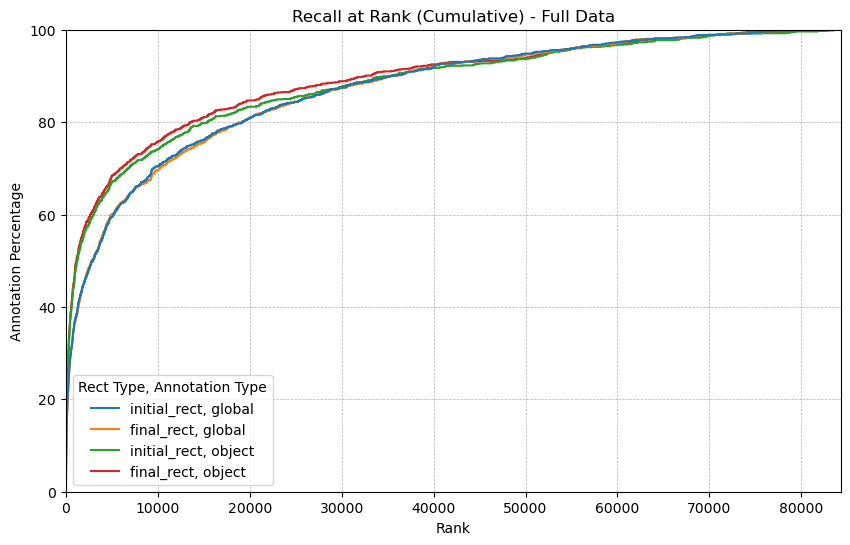

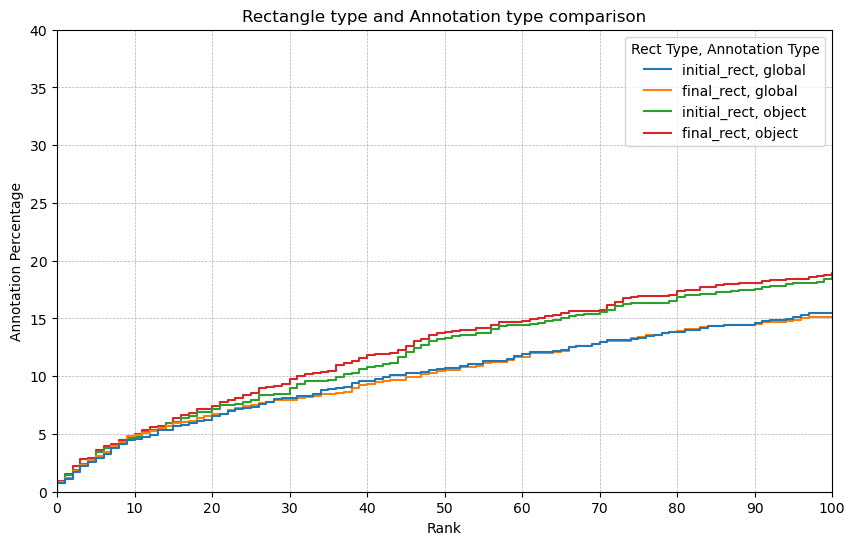

In [18]:
# Plot cumulative graphs
filtered = get_filtered_ranks(kind="centerpiece_10")

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Percentage")
ax.grid(True, which="both", linestyle='--', linewidth=0.5)

# Create hue for better distinction
hue = filtered[["rect_type", "annotation_type"]].apply(lambda row: f"{row.rect_type}, {row.annotation_type}", axis=1)
hue.name = "Rect Type, Annotation Type"

g = sns.ecdfplot(data=filtered, x="rank", hue=hue, stat="percent")
ax.set_xlim(0, dataset_size)
ax.set_ylim(0, 100)
g.set_title("Recall at Rank (Cumulative) - Full Data")
plt.show()

# Detail view (up to rank 100)
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Percentage")
ax.grid(True, which="both", linestyle='--', linewidth=0.5)

g = sns.ecdfplot(data=filtered, x="rank", hue=hue, stat="percent")
ax.set_xlim(0, 100)
ax.set_ylim(0, 40)  # Matching the scale from graphs.ipynb
# Add more ticks for better grid granularity in the zoomed view
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
g.set_title("Rectangle type and Annotation type comparison")
plt.show()

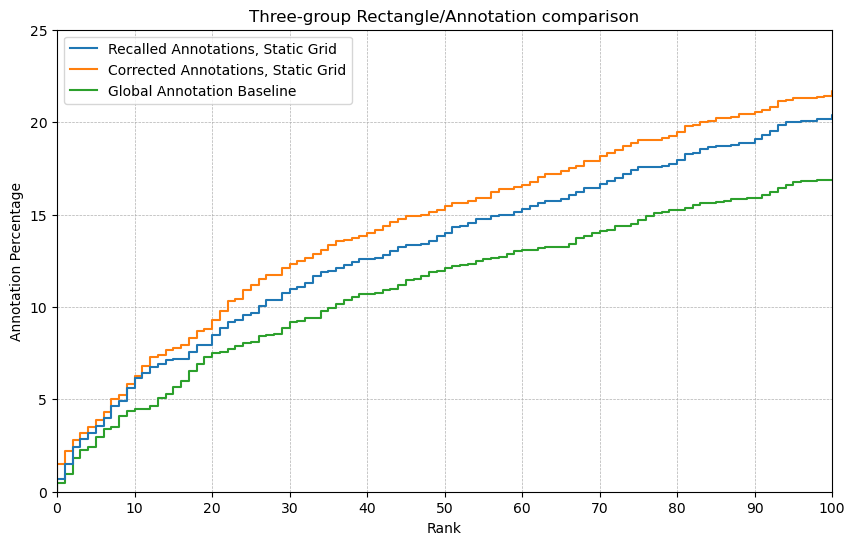

In [41]:
# Three-line comparison (similar to Rectangle type and Annotation type comparison)
subset_1 = get_filtered_ranks(rect_type="initial_rect", annotation_type="object", kind="9_piece_15").copy()
subset_1["comparison_group"] = "Recalled Annotations, Static Grid"

subset_2 = get_filtered_ranks(rect_type="final_rect", annotation_type="object", kind="9_piece_15").copy()
subset_2["comparison_group"] = "Corrected Annotations, Static Grid"

subset_3 = get_filtered_ranks(rect_type="initial_rect", annotation_type="global", kind="whole").copy()
subset_3["comparison_group"] = "Global Annotation Baseline"

filtered_three = pd.concat([subset_1, subset_2, subset_3], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Percentage")
ax.grid(True, which="both", linestyle='--', linewidth=0.5)

g = sns.ecdfplot(data=filtered_three, x="rank", hue="comparison_group", stat="percent")
legend = ax.get_legend()
if legend is not None:
    legend.set_title(None)
ax.set_xlim(0, 100)
ax.set_ylim(0, 25)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
g.set_title("Three-group Rectangle/Annotation comparison")
plt.show()

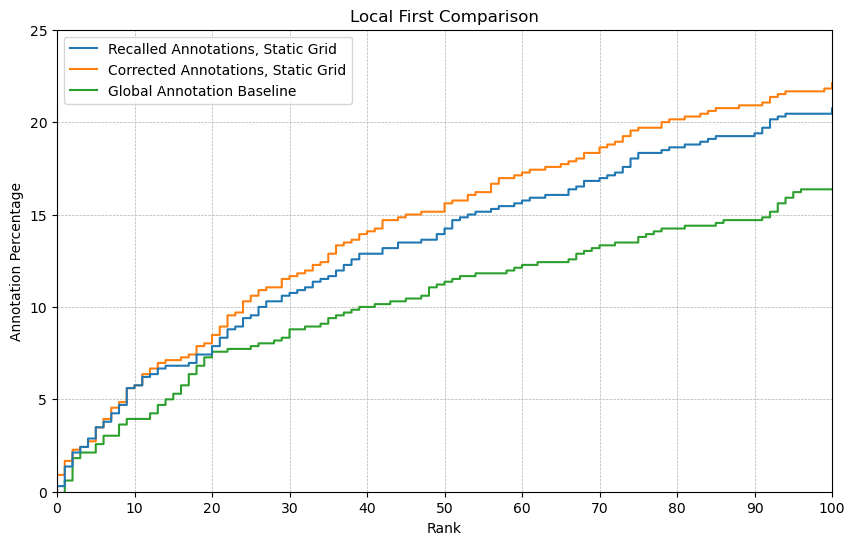

In [42]:
# Three-line comparison (similar to Rectangle type and Annotation type comparison)
subset_1 = get_filtered_ranks(rect_type="initial_rect", annotation_type="object", kind="9_piece_15", annotation_order="LF").copy()
subset_1["comparison_group"] = "Recalled Annotations, Static Grid"

subset_2 = get_filtered_ranks(rect_type="final_rect", annotation_type="object", kind="9_piece_15", annotation_order="LF").copy()
subset_2["comparison_group"] = "Corrected Annotations, Static Grid"

subset_3 = get_filtered_ranks(rect_type="initial_rect", annotation_type="global", kind="whole", annotation_order="LF").copy()
subset_3["comparison_group"] = "Global Annotation Baseline"

filtered_three = pd.concat([subset_1, subset_2, subset_3], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Percentage")
ax.grid(True, which="both", linestyle='--', linewidth=0.5)

g = sns.ecdfplot(data=filtered_three, x="rank", hue="comparison_group", stat="percent")
legend = ax.get_legend()
if legend is not None:
    legend.set_title(None)
ax.set_xlim(0, 100)
ax.set_ylim(0, 25)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
g.set_title("Local First Comparison")
plt.show()

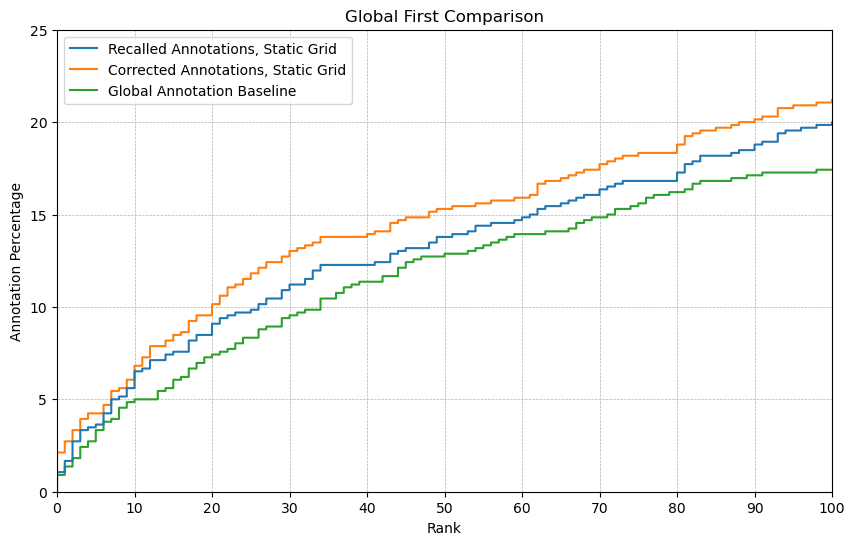

In [46]:
# Three-line comparison (similar to Rectangle type and Annotation type comparison)
subset_1 = get_filtered_ranks(rect_type="initial_rect", annotation_type="object", kind="9_piece_15", annotation_order="GF").copy()
subset_1["comparison_group"] = "Recalled Annotations, Static Grid"

subset_2 = get_filtered_ranks(rect_type="final_rect", annotation_type="object", kind="9_piece_15", annotation_order="GF").copy()
subset_2["comparison_group"] = "Corrected Annotations, Static Grid"

subset_3 = get_filtered_ranks(rect_type="initial_rect", annotation_type="global", kind="whole", annotation_order="GF").copy()
subset_3["comparison_group"] = "Global Annotation Baseline"

filtered_three = pd.concat([subset_1, subset_2, subset_3], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Percentage")
ax.grid(True, which="both", linestyle='--', linewidth=0.5)

g = sns.ecdfplot(data=filtered_three, x="rank", hue="comparison_group", stat="percent")
legend = ax.get_legend()
if legend is not None:
    legend.set_title(None)
ax.set_xlim(0, 100)
ax.set_ylim(0, 25)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.yaxis.set_major_locator(ticker.MultipleLocator(5)) 
g.set_title("Global First Comparison")
plt.show()

In [22]:
# Count where object annotation (centerpiece_10) beats global annotation (whole), split by annotation order
pair_keys = [
    "author",
    "annotation_id",
    "annotation_order",
    "model_year",
    "frame_idx",
]

object_cp10 = get_filtered_ranks(
    rect_type="initial_rect",
    annotation_type="object",
    kind="centerpiece_10",
)[pair_keys + ["rank"]].rename(columns={"rank": "rank_object_cp10"})

global_whole = get_filtered_ranks(
    rect_type="initial_rect",
    annotation_type="global",
    kind="whole",
)[pair_keys + ["rank"]].rename(columns={"rank": "rank_global_whole"})

comparison = object_cp10.merge(global_whole, on=pair_keys, how="inner")
comparison["object_better"] = comparison["rank_object_cp10"] < comparison["rank_global_whole"]

summary = (
    comparison.groupby("annotation_order", dropna=False)
    .agg(
        total_annotations=("object_better", "size"),
        object_better_count=("object_better", "sum"),
    )
    .reset_index()
    .sort_values("annotation_order")
)
summary["object_better_pct"] = 100 * summary["object_better_count"] / summary["total_annotations"]

display(summary)

,annotation_order,total_annotations,object_better_count,object_better_pct
0,GF,660,312,47.272727
1,LF,660,391,59.242424


2640


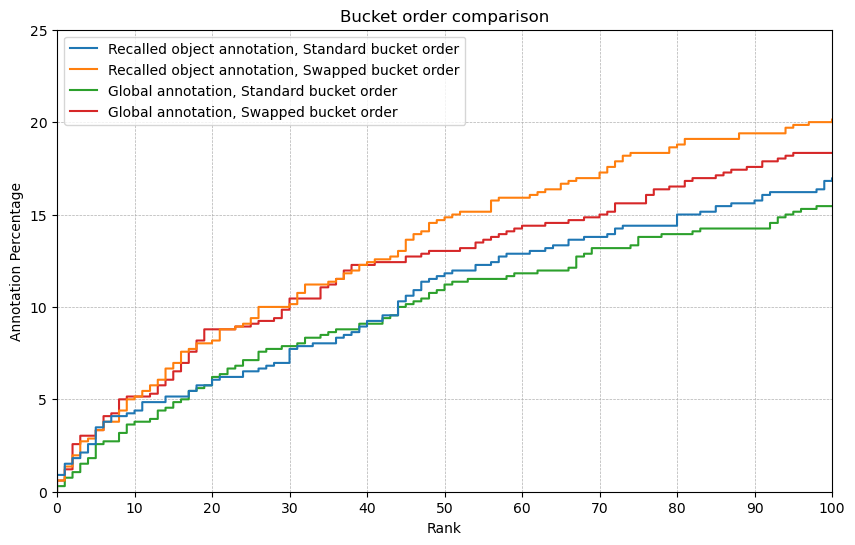

In [23]:
subset_1 = get_filtered_ranks(rect_type="initial_rect", annotation_type="object", kind="centerpiece_10", bucket_order="STD").copy()
subset_1["comparison_group"] = "Recalled object annotation, Standard bucket order"

subset_2 = get_filtered_ranks(rect_type="initial_rect", annotation_type="object", kind="centerpiece_10", bucket_order="SWP").copy()
subset_2["comparison_group"] = "Recalled object annotation, Swapped bucket order"

subset_3 = get_filtered_ranks(rect_type="initial_rect", annotation_type="global", kind="whole", bucket_order="STD").copy()
subset_3["comparison_group"] = "Global annotation, Standard bucket order"

subset_4 = get_filtered_ranks(rect_type="initial_rect", annotation_type="global", kind="whole", bucket_order="SWP").copy()
subset_4["comparison_group"] = "Global annotation, Swapped bucket order"

filtered_three = pd.concat([subset_1, subset_2, subset_3, subset_4], ignore_index=True)

print(len(filtered_three))

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Percentage")
ax.grid(True, which="both", linestyle='--', linewidth=0.5)

g = sns.ecdfplot(data=filtered_three, x="rank", hue="comparison_group", stat="percent")
legend = ax.get_legend()
if legend is not None:
    legend.set_title(None)
ax.set_xlim(0, 100)
ax.set_ylim(0, 25)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
g.set_title("Bucket order comparison")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


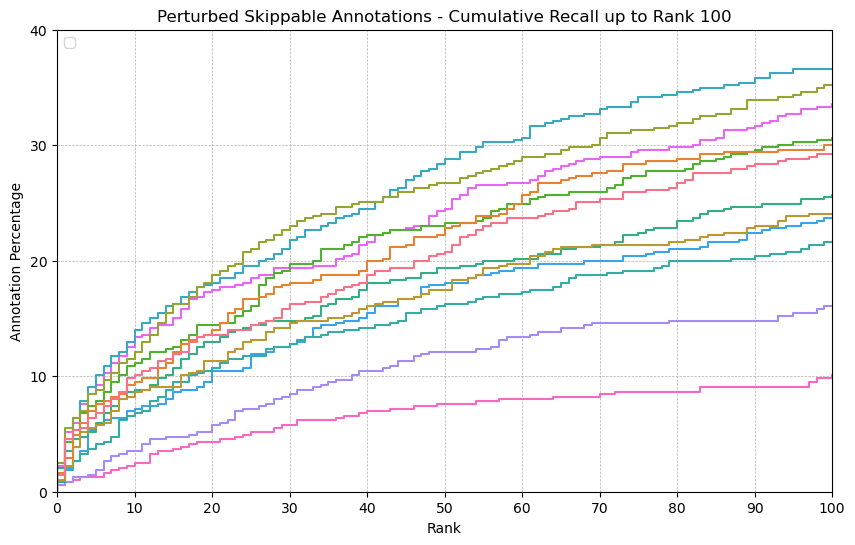

In [24]:
# Read perturbed skippable annotations and plot cumulative recall up to rank 100
perturbed = pd.read_csv("results2/perturbed_skippable_annotations.csv", index_col=0)
cols = list(perturbed.columns)
# find 'rect' column and take all columns after it
if 'rect' in cols:
    idx = cols.index('rect')
    target_cols = cols[idx+1:]
else:
    # fallback: look for any column name containing 'rect' (case-insensitive)
    idx = next((i for i,c in enumerate(cols) if 'rect' in c.lower()), None)
    target_cols = cols[idx+1:] if idx is not None else []
rows = []
for col in target_cols:
    vals = pd.to_numeric(perturbed[col], errors='coerce').dropna()
    rows.extend({'column': col, 'rank': v} for v in vals)
if not rows:
    print("No target columns found after 'rect' or no numeric data to plot.")
else:
    df_melt = pd.DataFrame(rows)
    plt.figure(figsize=(10, 6))
    ax = sns.ecdfplot(data=df_melt, x='rank', hue='column', stat='percent')
    ax.set_xlabel("Rank")
    ax.set_ylabel("Annotation Percentage")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 40)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title(None)
        ax.legend(loc='upper left')
    ax.set_title("Perturbed Skippable Annotations - Cumulative Recall up to Rank 100")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

,column,recall@1 (%),recall@10 (%),recall@100 (%),recall@1000 (%),avg_rank
0,Whole-Image Baseline (Global Annotations),0,4,17,43,8660.99
1,Whole-Image Baseline (Object Annotations),0,4,15,39,11605.17
2,Static Recalled (9_piece_0),1,5,17,41,12932.04
3,Static Recalled (9_piece_5),1,6,17,45,10886.59
4,Static Recalled (9_piece_10),1,5,19,46,9546.48
5,Static Recalled (9_piece_15),1,6,20,48,8956.30
6,Static Recalled (9_piece_20),1,5,19,48,9201.61
7,Static Recalled (9_piece_25),1,5,19,46,9681.21
8,Static Recalled (9_piece_40),1,4,16,42,10073.17
9,Static Recalled (centerpiece_0),1,5,17,45,10372.65


Exported to results2/recall_summary.txt


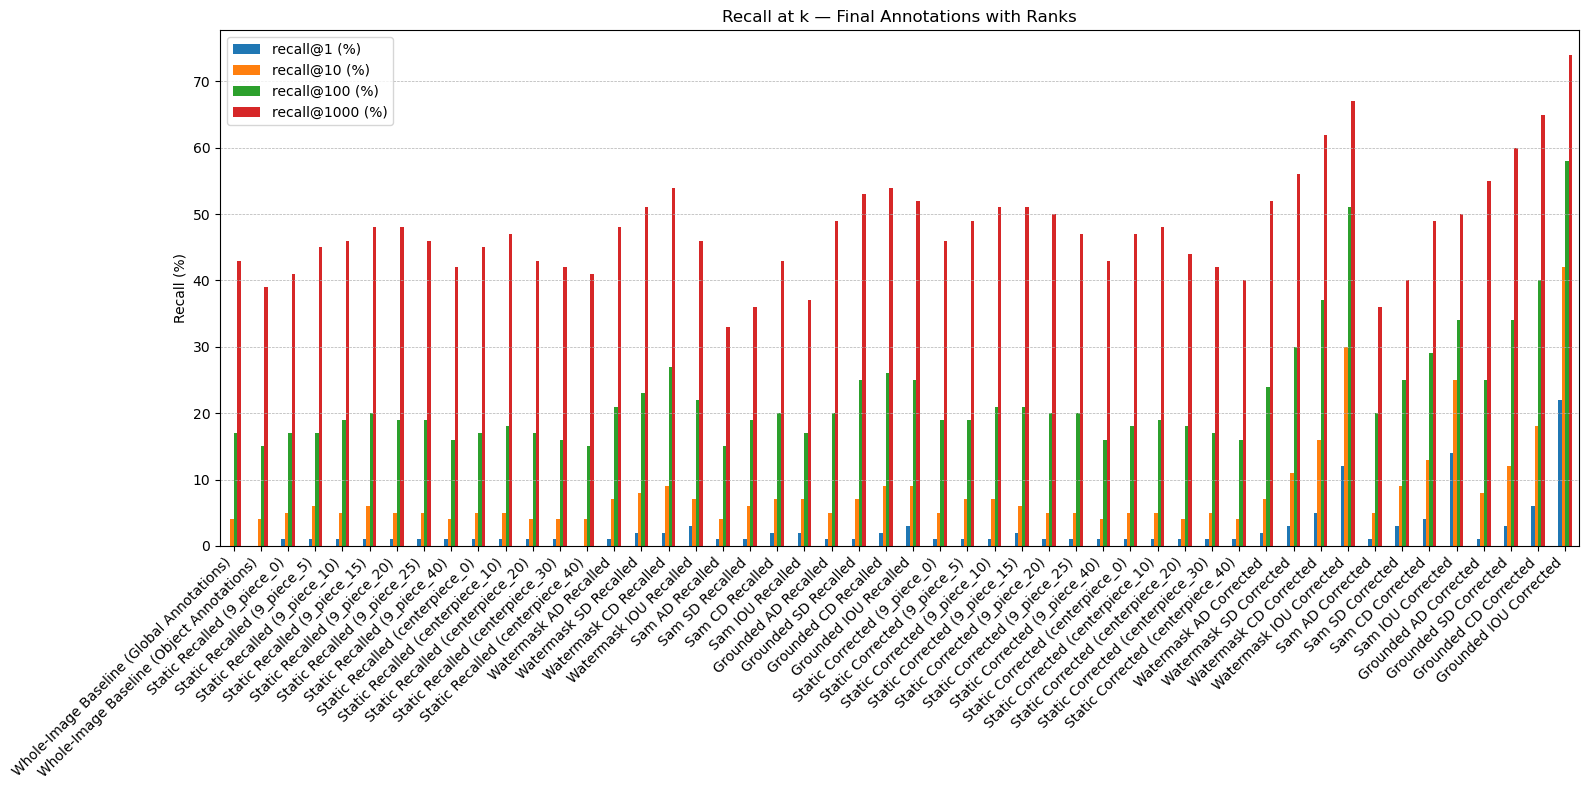

In [37]:
import re

def prettify_col(name: str) -> str:
    """rank_watermask_ad_linear_final_rect -> Watermask AD Corrected"""
    s = name
    s = re.sub(r'^rank_', '', s)       # drop "rank_" prefix
    s = s.replace('_', ' ')            # underscores -> spaces
    s = re.sub(r'\blinear\b', '', s)   # drop "linear"
    s = re.sub(r'\brect\b', '', s)     # drop "rect"
    s = re.sub(r'\s+', ' ', s).strip() # collapse whitespace
    # Capitalize specific tokens, title-case the rest
    parts = s.split()
    upper_tokens = {'ad', 'sd', 'cd', 'iou'}
    parts = [p.upper() if p.lower() in upper_tokens else p.capitalize() for p in parts]
    label = ' '.join(parts)
    # Rename Initial -> Recalled, Final -> Corrected
    label = label.replace("Initial", "Recalled").replace("Final", "Corrected")
    return label

def compute_recall_row(label: str, ranks_series):
    """Build a summary dict from a series of rank values."""
    vals = pd.to_numeric(ranks_series, errors="coerce").dropna()
    total = len(vals)
    row = {"column": label}
    for t in thresholds:
        count = (vals < t).sum()
        row[f"recall@{t} (%)"] = round(100 * count / total) if total > 0 else 0
    row["avg_rank"] = round(vals.mean(), 2) if total > 0 else None
    return row

# --- Thresholds ---
thresholds = [1, 10, 100, 1000]

# --- Static kind variants ---
static_kinds = [
    "9_piece_0",
    "9_piece_5",
    "9_piece_10",
    "9_piece_15",
    "9_piece_20",
    "9_piece_25",
    "9_piece_40",
    "centerpiece_0",
    "centerpiece_10",
    "centerpiece_20",
    "centerpiece_30",
    "centerpiece_40",
]

# --- Baseline: whole-image global & object ---
baseline_global = get_filtered_ranks(rect_type="initial_rect", annotation_type="global", kind="whole")
row_global = compute_recall_row("Whole-Image Baseline (Global Annotations)", baseline_global["rank"])

baseline_object = get_filtered_ranks(rect_type="initial_rect", annotation_type="object", kind="whole")
row_object = compute_recall_row("Whole-Image Baseline (Object Annotations)", baseline_object["rank"])

# --- Static recalled & corrected rows for each kind ---
static_recalled_rows = []
static_corrected_rows = []
for kind in static_kinds:
    recalled = get_filtered_ranks(rect_type="initial_rect", annotation_type="object", kind=kind)
    corrected = get_filtered_ranks(rect_type="final_rect", annotation_type="object", kind=kind)
    static_recalled_rows.append(compute_recall_row(f"Static Recalled ({kind})", recalled["rank"]))
    static_corrected_rows.append(compute_recall_row(f"Static Corrected ({kind})", corrected["rank"]))

# --- Rows from finalAnnotationsWithRanks.csv ---
final_ann = pd.read_csv("results2/finalAnnotationsWithRanks.csv", index_col=0)
cols = list(final_ann.columns)
desc_obj_idx = cols.index("desc_object")
rank_cols = cols[desc_obj_idx + 1:]

recalled_rows = []
corrected_rows = []
for col in rank_cols:
    vals = pd.to_numeric(final_ann[col], errors="coerce").dropna()
    pretty = prettify_col(col)
    row = compute_recall_row(pretty, vals)
    if "Recalled" in pretty:
        recalled_rows.append(row)
    elif "Corrected" in pretty:
        corrected_rows.append(row)
    else:
        recalled_rows.append(row)  # fallback

# Assemble: global baseline, object baseline, static recalled, grounded recalled, static corrected, grounded corrected
all_rows = (
    [row_global, row_object]
    + static_recalled_rows
    + recalled_rows
    + static_corrected_rows
    + corrected_rows
)
recall_df = pd.DataFrame(all_rows)

# Display the full table
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None):
    display(recall_df)

# Export the table to a fixed-width .txt file
data_cols = [c for c in recall_df.columns if c != "column"]
name_width = max(recall_df["column"].str.len().max(), len("column")) + 2
col_widths = {c: max(len(c), recall_df[c].astype(str).str.len().max()) + 2 for c in data_cols}

with open("results2/recall_summary.txt", "w") as f:
    header = "column".ljust(name_width) + "".join(c.rjust(col_widths[c]) for c in data_cols)
    f.write(header + "\n")
    f.write("-" * len(header) + "\n")
    for _, row in recall_df.iterrows():
        line = str(row["column"]).ljust(name_width)
        for c in data_cols:
            line += str(row[c]).rjust(col_widths[c])
        f.write(line + "\n")

print("Exported to results2/recall_summary.txt")

# Bar chart of recall percentages
recall_pct_cols = [f"recall@{t} (%)" for t in thresholds]
plot_df = recall_df.set_index("column")[recall_pct_cols]

fig, ax = plt.subplots(figsize=(16, 8))
plot_df.plot(kind="bar", ax=ax)
ax.set_ylabel("Recall (%)")
ax.set_xlabel("")
ax.set_title("Recall at k — Final Annotations with Ranks")
ax.legend(loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()


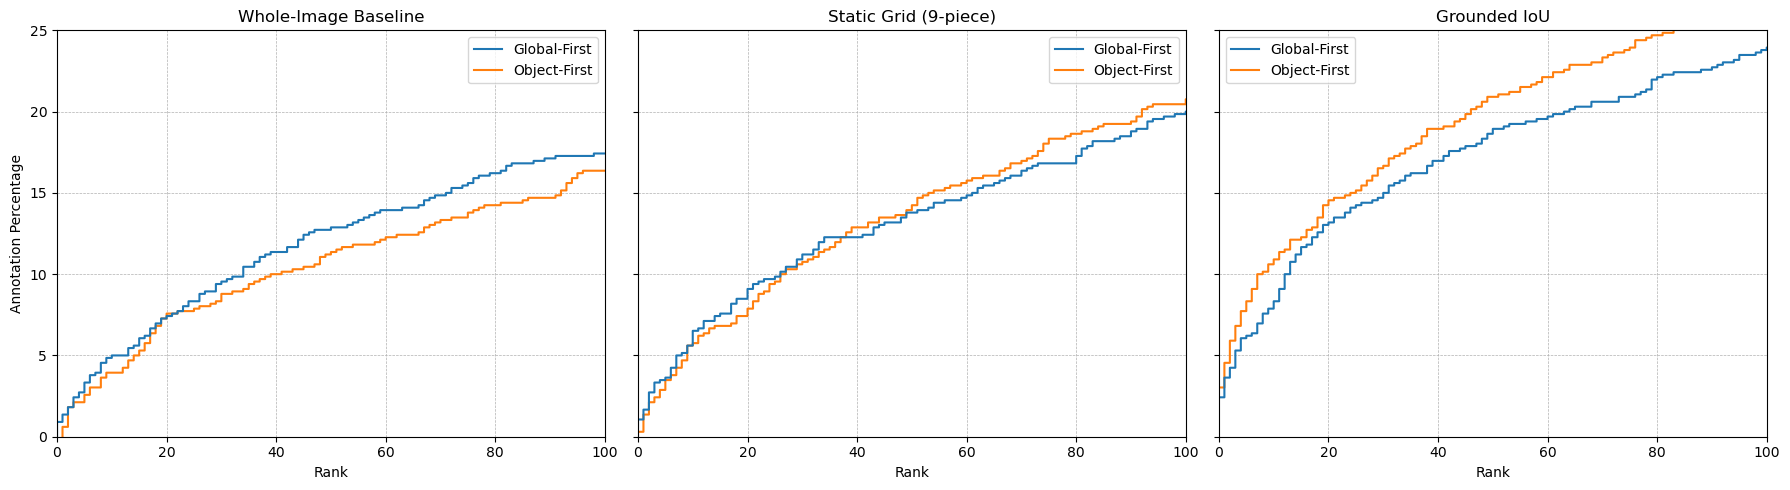

In [51]:
# Side-by-side: Whole-Image Baseline | Static Grid | Grounded IoU  (GF vs LF)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# --- 1. Whole-Image Baseline (global annotations, whole) ---
ax = axes[0]
s1 = get_filtered_ranks(rect_type="initial_rect", annotation_type="global", kind="whole", annotation_order="GF").copy()
s1["group"] = "Global-First"
s2 = get_filtered_ranks(rect_type="initial_rect", annotation_type="global", kind="whole", annotation_order="LF").copy()
s2["group"] = "Object-First"
combined = pd.concat([s1, s2], ignore_index=True)
sns.ecdfplot(data=combined, x="rank", hue="group", stat="percent", ax=ax)
leg = ax.get_legend()
if leg:
    leg.set_title(None)
ax.set_xlim(0, 100)
ax.set_ylim(0, 25)
ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Percentage")
ax.set_title("Whole-Image Baseline")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

# --- 2. Static Grid (object annotations, 9_piece_15) ---
ax = axes[1]
s1 = get_filtered_ranks(rect_type="initial_rect", annotation_type="object", kind="9_piece_15", annotation_order="GF").copy()
s1["group"] = "Global-First"
s2 = get_filtered_ranks(rect_type="initial_rect", annotation_type="object", kind="9_piece_15", annotation_order="LF").copy()
s2["group"] = "Object-First"
combined = pd.concat([s1, s2], ignore_index=True)
sns.ecdfplot(data=combined, x="rank", hue="group", stat="percent", ax=ax)
leg = ax.get_legend()
if leg:
    leg.set_title(None)
ax.set_xlim(0, 100)
ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax.set_xlabel("Rank")
ax.set_ylabel("")
ax.set_title("Static Grid (9-piece)")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

# --- 3. Grounded IoU (from finalAnnotationsWithRanks.csv) ---
ax = axes[2]
grounded_col = "rank_grounded_iou_linear_initial_rect"
gf_vals = pd.to_numeric(final_ann.loc[final_ann["annotation_order"] == "GF", grounded_col], errors="coerce").dropna()
lf_vals = pd.to_numeric(final_ann.loc[final_ann["annotation_order"] == "LF", grounded_col], errors="coerce").dropna()
combined = pd.concat([
    pd.DataFrame({"rank": gf_vals, "group": "Global-First"}),
    pd.DataFrame({"rank": lf_vals, "group": "Object-First"}),
], ignore_index=True)
sns.ecdfplot(data=combined, x="rank", hue="group", stat="percent", ax=ax)
leg = ax.get_legend()
if leg:
    leg.set_title(None)
ax.set_xlim(0, 100)
ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
ax.set_xlabel("Rank")
ax.set_ylabel("")
ax.set_title("Grounded IoU")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()
